In [1]:
import sys
python_path = sys.executable
print(python_path)


/usr/bin/python3.8


In [2]:
import gc
import os
import random
import time
from pathlib import Path
import glob

import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
from sklearn.model_selection import train_test_split

# INFO messages are not printed.
# This must be run before loading other modules.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


In [3]:
import numpy as np
numpy_location = np.__file__
print(numpy_location)
import cv2
import openslide
import pandas as pd

import numpy as np
import cv2
import random


/usr/local/lib/python3.8/dist-packages/numpy/__init__.py


In [4]:
import tensorflow_similarity as tfsim
import tensorflow_similarity.visualization as tfsim_visualization
import tensorflow_similarity.callbacks as tfsim_callbacks
import tensorflow_similarity.augmenters as tfsim_augmenters
import tensorflow_similarity.losses as tfsim_losses
import tensorflow_similarity.architectures as tfsim_architectures

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib


In [5]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_addons as tfa 
from tensorflow.keras.layers import AveragePooling2D, Dense, Flatten

/usr/local/lib/python3.8/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [6]:
print("TensorFlow:", tf.__version__)
print("TensorFlow Similarity", tfsim.__version__)

TensorFlow: 2.12.0
TensorFlow Similarity 0.17.1


In [7]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
        
        



In [8]:
def get_train_val_lists(csv_path):
    slide_list = pd.read_csv(csv_path)
    slide_list = slide_list.drop_duplicates(subset='slide_id', keep='first')
    aneuploid_list = slide_list.loc[slide_list['label'] == 'diploid', 'slide_id']
    diploid_list = slide_list.loc[slide_list['label'] == 'diploid', 'slide_id']


    # Split the lists into training and validation sets
    train_aneuploid, val_aneuploid = train_test_split(aneuploid_list, test_size=0.2, random_state=42)
    train_diploid, val_diploid = train_test_split(diploid_list, test_size=0.2, random_state=42)
    # Combine the lists 
    train_list = pd.concat([train_aneuploid, train_diploid], ignore_index=True)
    val_list = pd.concat([val_aneuploid, val_diploid], ignore_index=True)

    return train_list, val_list

def get_tif_files(base_path, csv_path):
    train_list, val_list = get_train_val_lists(csv_path)

    tif_files_train = []
    tif_files_val = []
    for slide_id in train_list:
        tif_files_train += glob.glob(f"{base_path}/{slide_id}*.tif")
    for slide_id in val_list:
        tif_files_val += glob.glob(f"{base_path}/{slide_id}*.tif")
    print(f"Number of training biopsies: {len(train_list)}")
    print(f"Number of validation biopsies: {len(val_list)}")

    return tif_files_train, tif_files_val

In [9]:
csv_path = "/rsrch5/home/trans_mol_path/cercan/BE_master/1.aneuploid/results/training_250131/sample_list_mda_12.csv"
base_path = "/rsrch5/home/trans_mol_path/cercan/BE_master/0.input/flow/roi/flow/MDA12_ROI_pyramid"


tif_files_train, tif_files_val = get_tif_files(base_path, csv_path)

Number of training biopsies: 474
Number of validation biopsies: 120


In [10]:
ALGORITHM = "simclr"

In [11]:
IMG_SIZE = 224
INIT_LR = 1e-3  # Initial LR for the learning rate schedule, see section B.1 in the paper.
TEMPERATURE = 0.5  # Tuned for CIFAR10, see section B.9 in the paper.

BATCH_SIZE = 64
PRE_TRAIN_EPOCHS = 20
PRE_TRAIN_STEPS_PER_EPOCH = len(tif_files_train) // BATCH_SIZE
VAL_STEPS_PER_EPOCH = 20
WEIGHT_DECAY = 5e-4
DIM = 1024  # The layer size for the projector and predictor models.
WARMUP_LR = 0.0
WARMUP_STEPS = 0

In [12]:



# def read_slide_image(file_path):
#     wsi = openslide.OpenSlide(file_path)
#     return wsi
    
# def tf_read_slide(file_path):
#     return tf.py_function(read_slide_image, [file_path], tf.uint8)



def parse_image_mask(file_path, sthresh =30):
    
    wsi = openslide.OpenSlide(file_path)
    level = wsi.get_best_level_for_downsample(64)
    image_ds = np.array(wsi.read_region((0, 0), level, wsi.level_dimensions[level]).convert('RGB'))
    img_gray = cv2.cvtColor(image_ds, cv2.COLOR_RGB2GRAY)
    img_blur = cv2.GaussianBlur(img_gray,(7,7),0)
    _, img_otsu = cv2.threshold(img_blur, sthresh, 220, cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)
    kernel = np.ones((2, 2), np.uint8)
    mask = cv2.morphologyEx(img_otsu, cv2.MORPH_CLOSE, kernel) 

    original_dimensions = wsi.level_dimensions[0] 
    mask = cv2.resize(mask, (original_dimensions[0], original_dimensions[1]), interpolation=cv2.INTER_NEAREST)
    image = np.array(wsi.read_region((0, 0), 0, wsi.level_dimensions[0]).convert('RGB'))

    return image, mask

# def parse_image_tf(filename):
#     image = tf.io.read_file(filename)
#     image = tf.image.decode_png(image, channels=3)
#     return image

def generate_random_crop_boundary(image_shape, crop_size):
        
    height, width = image_shape[:2]
    
  # Calculate y boundaries
    if height < crop_size:
        start_y = 0 
        end_y = height
    else:
        max_y = height - crop_size
        start_y = random.randint(0, max_y)
        end_y = start_y + crop_size
        
    # Calculate x boundaries (using width, not height)
    if width < crop_size:
        start_x = 0 
        end_x = width
    else:
        max_x = width - crop_size
        start_x = random.randint(0, max_x)
        end_x = start_x + crop_size
        
    return start_y, start_x, end_y, end_x

def check_tissue_content(mask, crop_start_y, crop_start_x, crop_dim = 448, threshold =0.5):
    crop_mask = mask[crop_start_y:crop_start_y+crop_dim, crop_start_x:crop_start_x+crop_dim]
    # crop_img =  img[crop_start_y:crop_start_y+crop_dim, crop_start_x:crop_start_x+crop_dim]
    
    #black ink test
    # gray = cv2.cvtColor(crop_img, cv2.COLOR_RGB2GRAY)
    # _, ink_mask = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY_INV)
    # ink_pixels = np.sum(ink_mask == 255)
    
    tissue_pixels = np.sum(crop_mask > 0)
    total_pixels = crop_mask.size
    
    # tissue_check_pass = ((tissue_pixels - ink_pixels) / total_pixels) >= threshold
    # black_ink_check_pass = (dark_pixels / total_pixels) <= 0.2

    return (tissue_pixels  / total_pixels) >= threshold


def get_crops_bounds(mask, region_dim= 1024, crop_dim = 448, max_attempts = 20):
    threshold =0.5
    for _ in range(max_attempts):
        crop_start_y, crop_start_x, _, _ = generate_random_crop_boundary((region_dim,region_dim), crop_dim)
    
        if check_tissue_content(mask, crop_start_y, crop_start_x):
            crop_bounds = (crop_start_y, crop_start_x)
            return crop_bounds
        else:
            threshold -= 0.05

    return None



def get_crops(filename, region_dim = 1024, crop_dim = 448):
    wsi_img, wsi_mask = parse_image_mask(filename)
    # print(wsi_img.shape)
    # print(wsi_mask.shape)

    valid_patch = False
    crops = []
    while not valid_patch:
        region_start_y, region_start_x, end_y, end_x = generate_random_crop_boundary(wsi_mask.shape, region_dim)
        # print(str(region_start_y) +":"+ str(end_y))
        # print(str(region_start_x)+","+ str(end_x))
              
        region_mask = wsi_mask[region_start_y:end_y,
                               region_start_x:end_x].copy()
        
        crop_bounds = get_crops_bounds(region_mask, region_dim= region_dim, crop_dim = crop_dim) # generates random boundery and tests tissue content. If no tissue content, returns None
        if crop_bounds is not None:
            region_img = wsi_img[region_start_y:end_y,
                               region_start_x:end_x].copy()
            img_crop = region_img[crop_bounds[0]:crop_bounds[0]+crop_dim,
                               crop_bounds[1]:crop_bounds[1]+crop_dim].copy()
            # img_crop = tf.image.crop_to_bounding_box(
            #     region_img,
            #     offset_height=crop_bounds[0],
            #     offset_width=crop_bounds[1],
            #     target_height=crop_dim,
            #     target_width=crop_dim
            # )
            img_crop = tf.convert_to_tensor(img_crop, dtype=tf.float32)
            crops.append(img_crop)
            if len(crops) == 2:
                valid_patch = True

    return crops

def simsiam_augmenter(img):

    # The following transforms expect the data to be [0, 1]
    img = tf.convert_to_tensor(img)
    img = tf.cast(img, tf.float32)
    # print(img.shape)
    # img = tf.image.resize_with_pad(img, target_height=448, target_width=448)
    try:
        img = tf.image.resize(img, [224,224])
    except Exception as e:
        fallback_image = tf.zeros((448, 448, 3), dtype=tf.float32)
        fallback_image = tf.identity(img)
        img = tf.image.resize(fallback_image, [224,224])
        
    
    # Normalize to [0, 1]
    img /= 255.0

    # random color jitter
    def _jitter_transform(x):
        return tfsim.augmenters.augmentation_utils.color_jitter.color_jitter_rand(
            x,
            np.random.uniform(0.0, 0.4), #brightness
            np.random.uniform(0.0, 0.4), #contrast
            np.random.uniform(0.0, 0.4), #saturation
            np.random.uniform(0.0, 0.1), #hue
            "multiplicative",
        )
    try:
        img = tfsim.augmenters.augmentation_utils.random_apply.random_apply(_jitter_transform, p=0.8, x=img)
    except Exception as e:
        pass

    # # random grayscale
    def _grascayle_transform(x):
        return tfsim.augmenters.augmentation_utils.color_jitter.to_grayscale(x)

    try:
        img = tfsim.augmenters.augmentation_utils.random_apply.random_apply(_grascayle_transform, p=0.05, x=img)
    except Exception as e:
        pass

    # print(f"Image shape before blur: {img.shape}")
    try:
        img = tfsim.augmenters.augmentation_utils.blur.random_blur(img, height=7, width=7, min_sigma=0.2, max_sigma=1.2, p=0.5)
    except Exception as e:
        pass
    
    try:
        # random horizontal flip
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
    except Exception as e:
        pass

    # scale the data back to [0, 255]
    img = img * 255.0
    img = tf.clip_by_value(img, 0.0, 255.0)

    return img


def get_views(file_path):
    # wsi to crops
    file_path = file_path.numpy().decode()
    crops = get_crops(file_path)
    #reduce augmenter to only transformations
    view1 = simsiam_augmenter(crops[0])
    # view1 = img_scaling(view1)
    view2 = simsiam_augmenter(crops[1])
    # view2 = img_scaling(view2)
    
    view1.set_shape((224, 224, 3))
    view2.set_shape((224, 224, 3))
    
    return view1, view2

@tf.function
def tf_read_slide(file_path):
    view1, view2 = tf.py_function(get_views, [file_path], [tf.float32, tf.float32])
    # Set shapes again after py_function
    view1.set_shape((224,224,3))
    view2.set_shape((224,224,3))
    # If your model expects a single input, you might need to combine the views accordingly.
    return view1, view2


In [13]:
BATCH_SIZE=128
train_ds = tf.data.Dataset.from_tensor_slices(tif_files_train)
train_ds = train_ds.repeat()
train_ds = train_ds.shuffle(1024)
train_ds = train_ds.map(tf_read_slide, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(tif_files_val)
val_ds = val_ds.repeat()
val_ds = val_ds.shuffle(1024)
val_ds = val_ds.map(tf_read_slide, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


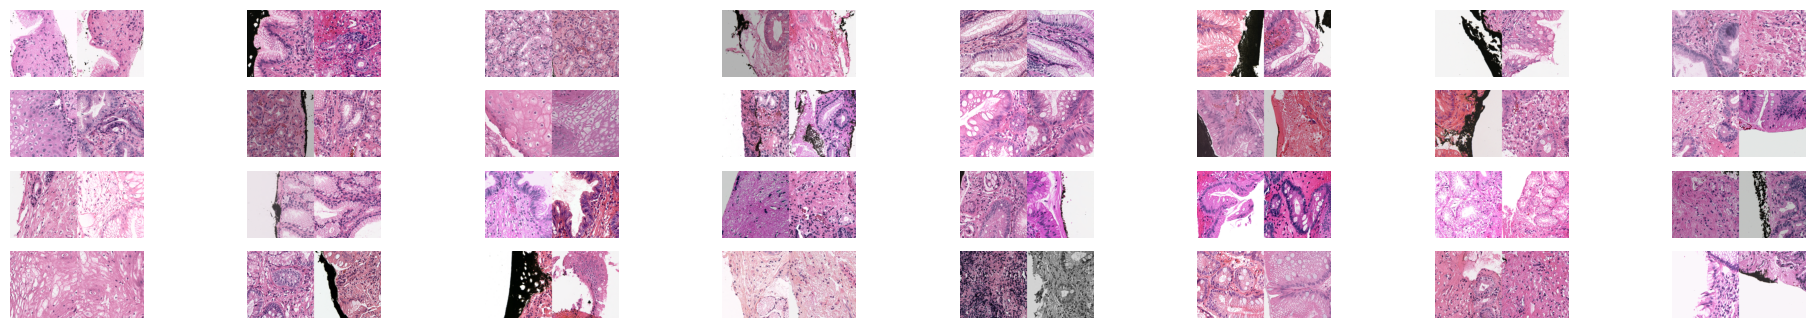

In [14]:
display_imgs = next(train_ds.as_numpy_iterator())
max_pixel = np.max([display_imgs[0].max(), display_imgs[1].max()])
min_pixel = np.min([display_imgs[0].min(), display_imgs[1].min()])

tfsim_visualization.visualize_views(
    views=display_imgs,
    num_imgs=32,
    views_per_col=8,
    max_pixel_value=max_pixel,
    min_pixel_value=min_pixel,
)

In [15]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [16]:
device = '/gpu:0' if tf.config.list_physical_devices('GPU') else '/cpu:0'
print(device)

/gpu:0


In [17]:
foundation_model_base = '/rsrch5/home/trans_mol_path/cercan/foundationModels/physionet.org/files/medical-ai-research-foundation/1.0.0/'
def foundationModel(arch = 'path-50x1-remedis-s',no_linear=False, noAverage = False, trainable = False):
    device = '/gpu:0' if tf.config.list_physical_devices('GPU') else '/cpu:0'
    # load_options = tf.saved_model.LoadOptions(experimental_io_device='/job:localhost')

    with tf.device(device):
        hub_path = os.path.join(foundation_model_base,arch)

        module_keras=hub.KerasLayer(hub_path, trainable=trainable)

        model = tf.keras.Sequential(module_keras)
        model.build(input_shape=(None, 224,224,3))
        #model.add(Flatten()) # avrpool
        if not noAverage:
            model.add(AveragePooling2D(pool_size=(7, 7))) #TODO change to trainable conv layer
            model.add(Flatten())
        if not no_linear:
            model.add(Dense(1024, activation= None,use_bias=False)) # input_shape=(131072,)

    return model
arch = 'path-152x2-remedis-s'
remedis_model = foundationModel(arch = arch)
remedis_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 7, 7, 4096)        232230016 
                                                                 
 average_pooling2d (AverageP  (None, 1, 1, 4096)       0         
 ooling2D)                                                       
                                                                 
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 dense (Dense)               (None, 1024)              4194304   
                                                                 
Total params: 236,424,320
Trainable params: 4,194,304
Non-trainable params: 232,230,016
_________________________________________________________________


In [18]:
projector = None
predictor = None

In [19]:
with tf.device('/GPU:0'):  # Use '/GPU:0' for the first GPU, or '/GPU:1' for the second GPU, etc.
    contrastive_model = tfsim.models.create_contrastive_model(
        backbone=remedis_model,
        projector=projector,
        predictor=predictor,
        algorithm=ALGORITHM,
        name=ALGORITHM,
    )


In [20]:
# elif ALGORITHM == "simclr":
loss = tfsim_losses.SimCLRLoss(name=ALGORITHM, temperature=TEMPERATURE)
optimizer = tfa.optimizers.LAMB(learning_rate=INIT_LR)

In [21]:
with tf.device('/GPU:0'): 
    contrastive_model.compile(
    optimizer=optimizer,
    loss=loss,
)

In [22]:
DATA_PATH = Path('/rsrch5/home/trans_mol_path/cercan/foundationModels/finetuned/')


log_dir = DATA_PATH / arch / "models"  / "logs" / f"{loss.name}_{time.time()}"
chkpt_dir = DATA_PATH / arch / "models" / "checkpoints" / f"{loss.name}_{time.time()}"


# evb = tfsim_callbacks.EvalCallback(
#     img_scaling(tf.cast(x_query, tf.float32)),
#     y_query,
#     img_scaling(tf.cast(x_index, tf.float32)),
#     y_index,
#     metrics=["binary_accuracy"],
#     k=1,
#     tb_logdir=log_dir,
# )
tbc = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    update_freq=100,
)
mcp = tf.keras.callbacks.ModelCheckpoint(
    filepath=chkpt_dir,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
)

In [23]:
history = contrastive_model.fit(
    train_ds,
    epochs=PRE_TRAIN_EPOCHS,
    steps_per_epoch=PRE_TRAIN_STEPS_PER_EPOCH,
    validation_data=val_ds,
    validation_steps=VAL_STEPS_PER_EPOCH,
    callbacks=[tbc, mcp],
    verbose=1,
)

Epoch 1/20
 4/14 [=======>......................] - ETA: 1:59 - loss: 10.2691 - proj_std: 0.0441 

InvalidArgumentError: Graph execution error:

2 root error(s) found.
  (0) INVALID_ARGUMENT:  ValueError: Tensor's shape (224, 224, 9) is not compatible with supplied shape (224, 224, 3).
Traceback (most recent call last):

  File "/usr/local/lib/python3.8/dist-packages/tensorflow/python/ops/script_ops.py", line 265, in __call__
    return func(device, token, args)

  File "/usr/local/lib/python3.8/dist-packages/tensorflow/python/ops/script_ops.py", line 143, in __call__
    outputs = self._call(device, args)

  File "/usr/local/lib/python3.8/dist-packages/tensorflow/python/ops/script_ops.py", line 150, in _call
    ret = self._func(*args)

  File "/usr/local/lib/python3.8/dist-packages/tensorflow/python/autograph/impl/api.py", line 642, in wrapper
    return func(*args, **kwargs)

  File "/tmp/ipykernel_3801/1387627806.py", line 197, in get_views
    view2.set_shape((224, 224, 3))

  File "/usr/local/lib/python3.8/dist-packages/tensorflow/python/framework/ops.py", line 1305, in set_sh

In [ ]:
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history["loss"])
plt.grid()
plt.title(f"{loss.name} - loss")

plt.subplot(1, 3, 2)
plt.plot(history.history["proj_std"], label="proj")
if "pred_std" in history.history:
    plt.plot(history.history["pred_std"], label="pred")
plt.grid()
plt.title(f"{loss.name} - std metrics")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history["binary_accuracy"], label="acc")
plt.grid()
plt.title(f"{loss.name} - match metrics")
plt.legend()

plt.show()

In [ ]:
contrastive_model.summary()

In [ ]:
del contrastive_model
del remedis_model

In [ ]:

remedis_model_2 = foundationModel(arch = arch, trainable= True)
remedis_model_2.summary()



In [ ]:
with tf.device('/GPU:0'):  # Use '/GPU:0' for the first GPU, or '/GPU:1' for the second GPU, etc.
    contrastive_model_step2 = tfsim.models.create_contrastive_model(
        backbone=remedis_model_2,
        projector=projector,
        predictor=predictor,
        algorithm=ALGORITHM,
        name=ALGORITHM,
    )


In [ ]:
# elif ALGORITHM == "simclr":
loss = tfsim_losses.SimCLRLoss(name=ALGORITHM, temperature=TEMPERATURE)
optimizer = tfa.optimizers.LAMB(learning_rate=INIT_LR/10)

In [ ]:
with tf.device('/GPU:0'): 
    contrastive_model_step2.compile(
    optimizer=optimizer,
    loss=loss,
)

    
contrastive_model_step2.load_weights(chkpt_dir)

In [ ]:

PRE_TRAIN_EPOCHS = 20
PRE_TRAIN_STEPS_PER_EPOCH = len(tif_files_train) // BATCH_SIZE
VAL_STEPS_PER_EPOCH = len(tif_files_val) // BATCH_SIZE

In [ ]:

log_dir =  f"{log_dir}_step2"
chkpt_dir = f"{chkpt_dir}_step2"


# evb = tfsim_callbacks.EvalCallback(
#     img_scaling(tf.cast(x_query, tf.float32)),
#     y_query,
#     img_scaling(tf.cast(x_index, tf.float32)),
#     y_index,
#     metrics=["binary_accuracy"],
#     k=1,
#     tb_logdir=log_dir,
# )
tbc = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    update_freq=100,
)
mcp = tf.keras.callbacks.ModelCheckpoint(
    filepath=chkpt_dir,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
)

In [ ]:
BATCH_SIZE

In [ ]:
history = contrastive_model_step2.fit(
    train_ds,
    epochs=PRE_TRAIN_EPOCHS,
    steps_per_epoch=PRE_TRAIN_STEPS_PER_EPOCH,
    validation_data=val_ds,
    validation_steps=VAL_STEPS_PER_EPOCH,
    callbacks=[tbc, mcp],
    verbose=1,
)

In [ ]:

tf.saved_model.save(contrastive_model_step2, chkpt_dir)